Script for training Resnet (18, 50, 101), two protocols, retinotopic by integrating a log-polar transformation during re-training,
image maps without transformation but a circular mask is applied to the image. 

Test the 3 data sets:

* full (Imagenet full image) (done)
* square (the smallest square containing the bounding box) (done)
* focus (best point of fixation after a saccade)



In [1]:
from retinotopy import *
welcome()

---------------------------------------------------------------------------------
On date 2025-11-13, Running learning on host gaia with device mps, pytorch==2.9.1
---------------------------------------------------------------------------------
Welcome on macOS-26.1-arm64-arm-64bit-Mach-O


In [2]:
datetag

'2025-11-13'

# Transfer learning on the full and bbox datasets in Cartesian and retinotopic coordinates

Doing this for different ResNet flavors : 18, 50 and 101

data_set_type='full'
--------------------------------------------------
..................................................
Loading model_path=None
loading .... cached_data/resnet18.pth
Training model resnet18, file= cached_data/2025-11-13_full_resnet18_retino.pt - image_size=224
Loaded 50000 images under val
Loaded 1281166 images under train
cached_data/2025-11-13_full_resnet18_retino.pt - Epoch 0, i_image 250 : train= loss: 605.8597 / acc : 605.8597 - val= loss : 1226.7872 / acc : 0.1713 / time:89.5
cached_data/2025-11-13_full_resnet18_retino.pt - Epoch 0, i_image 20250 : train= loss: 506.8310 / acc : 506.8310 - val= loss : 788.7065 / acc : 0.3513 / time:204.0
cached_data/2025-11-13_full_resnet18_retino.pt - Epoch 0, i_image 40250 : train= loss: 428.4546 / acc : 428.4546 - val= loss : 738.7776 / acc : 0.3828 / time:317.8
cached_data/2025-11-13_full_resnet18_retino.pt - Epoch 0, i_image 60250 : train= loss: 405.4383 / acc : 405.4383 - val= loss : 713.8686 / acc : 0.3979 / time:426.8
ca

UnidentifiedImageError: Caught UnidentifiedImageError in DataLoader worker process 1.
Original Traceback (most recent call last):
  File "/Users/laurent/sdrive_cnrs/hot_from_git/Retinotopy_project/Retinotopy/.venv/lib/python3.13/site-packages/torch/utils/data/_utils/worker.py", line 349, in _worker_loop
    data = fetcher.fetch(index)  # type: ignore[possibly-undefined]
  File "/Users/laurent/sdrive_cnrs/hot_from_git/Retinotopy_project/Retinotopy/.venv/lib/python3.13/site-packages/torch/utils/data/_utils/fetch.py", line 52, in fetch
    data = [self.dataset[idx] for idx in possibly_batched_index]
            ~~~~~~~~~~~~^^^^^
  File "/Users/laurent/sdrive_cnrs/hot_from_git/Retinotopy_project/Retinotopy/.venv/lib/python3.13/site-packages/torchvision/datasets/folder.py", line 245, in __getitem__
    sample = self.loader(path)
  File "/Users/laurent/sdrive_cnrs/hot_from_git/Retinotopy_project/Retinotopy/.venv/lib/python3.13/site-packages/torchvision/datasets/folder.py", line 284, in defau

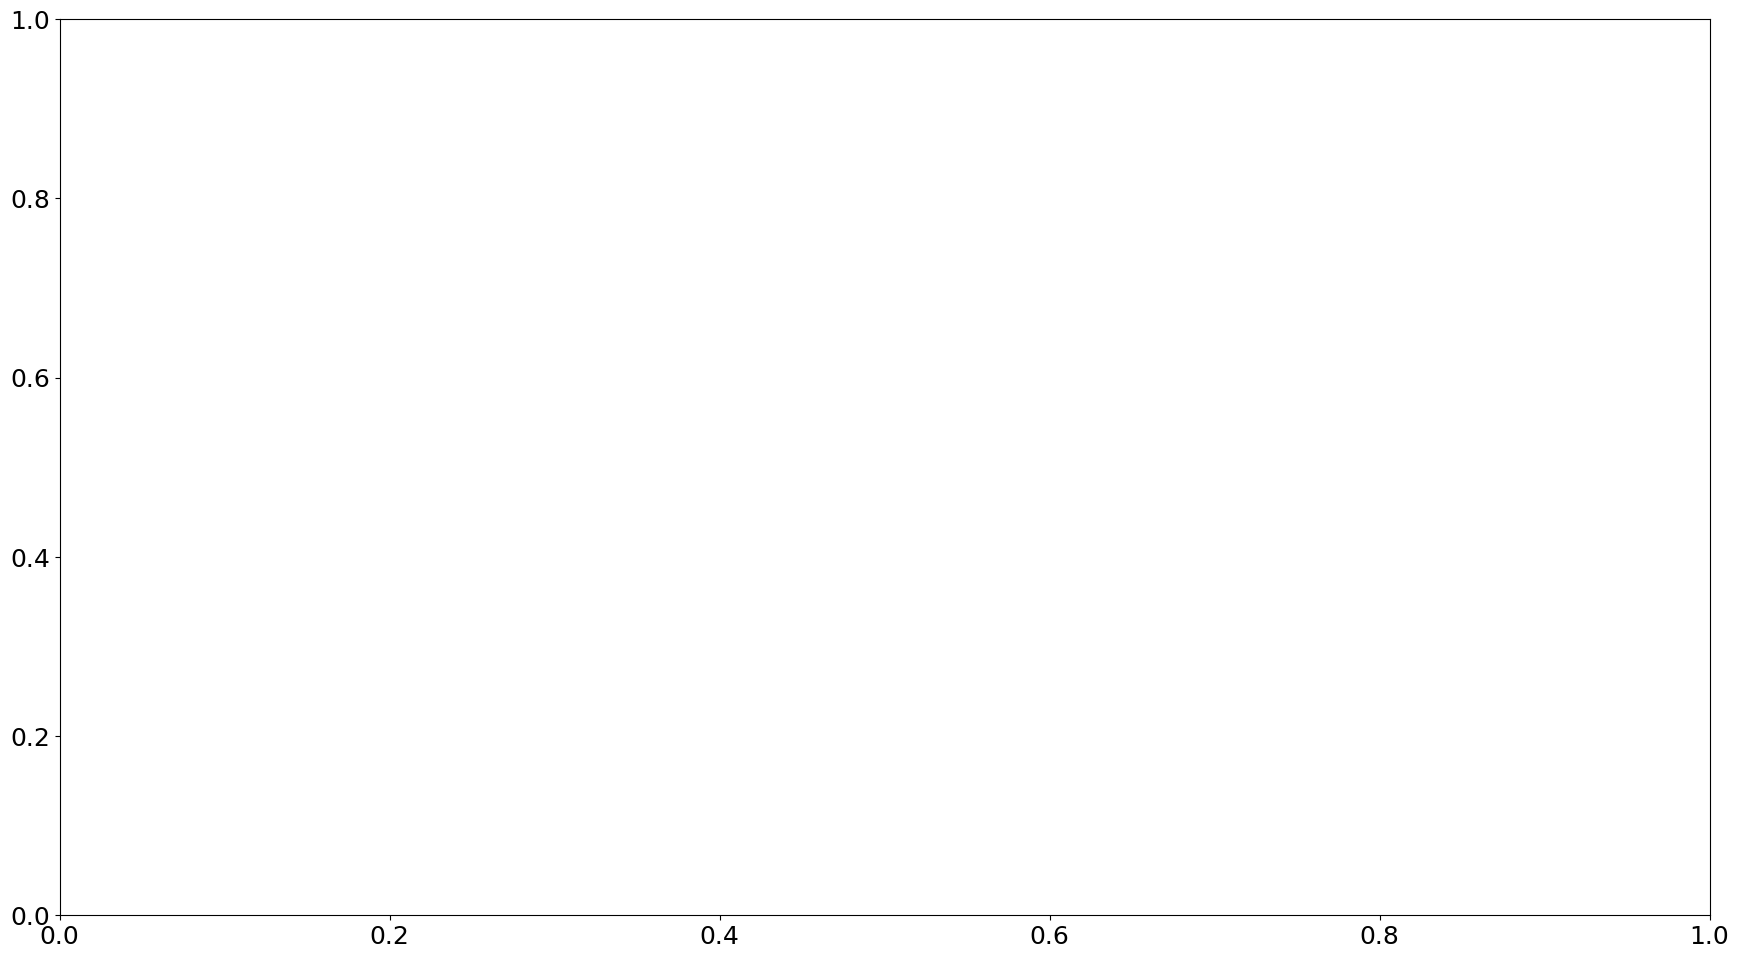

In [3]:
# Training and saving the networks
for data_set_type in data_set_types:
# for data_set_type in ['bbox']:
    
    print(50*'=')
    print(f'{data_set_type=}')
    print(50*'-')
    fig, ax = plt.subplots(1, 1, figsize=(fig_width, fig_width/phi), subplotpars=subplotpars)
        
    for model_name, lw in  zip(['resnet18', 'resnet50', 'resnet101'], [1, 2, 4]): #, 
        for do_polar, color in zip([True, False], ['b', 'r']):
            # setting parameters
            args = Params()
            args.root  = f'{DATAROOT}/Imagenet_{data_set_type}' # Directory containing images to perform the training
            args.do_polar = do_polar
            
            print(50*'.')
            model_filename = get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '.pt'
            json_filename = get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '.json'

            df_train = None
            should_resume_training = not os.path.isfile(model_filename + '.lock')
            
            if os.path.isfile(json_filename):
                print(f"Load JSON from pre-trained resnet {json_filename}")
                df_train = pd.read_json(json_filename, orient='index')
                print(f"{model_filename}: accuracy = {df_train['avg_acc_val'][-5:].mean():.3f}")
                should_resume_training = (df_train['epoch'].max() + 1 < args.num_epochs) and (not os.path.isfile(model_filename + '.lock'))

            if should_resume_training:
                touch(model_filename + '.lock') # as we do a training let's lock it
                if not os.path.isfile(model_filename):
                    # the learning has not been started yet
                    model_path = None if data_set_type == 'full' else get_filename(data_cache, datetag, 'full', model_name, do_polar) + '.pt' 
                else:
                    # the learning has been started, we want to load the model
                    model_path = get_filename(data_cache, datetag, data_set_type, model_name, do_polar) + '.pt' 
                
                # get the architecture of the network - will be trained from scratch or from a pre-trained model if model_path is None
                print(f"Loading {model_path=}")
                model_retrain = load_model(model_name=model_name, model_path=model_path, do_scratch=args.do_scratch, do_circular=args.do_polar).to(device)

                # we need to train the model or finish a training that already started
                print(f"Training model {model_name}, file= {model_filename} - image_size={args.image_size}")
                start_time = time.time()
                model_retrain, df_train = train_model(args, model=model_retrain, dataloaders=datasets_transforms(args), df_train=df_train, model_filename=model_filename)
                elapsed_time = time.time() - start_time
                print(f"Training completed in {elapsed_time // 60:.0f}m {elapsed_time % 60:.0f}s")

                print()     


            if not(df_train is None):
                trained_epochs = df_train['epoch'].max() + 1
                if trained_epochs < args.num_epochs:
                    print(f"Training in progress with {trained_epochs} ")
                else:
                    if os.path.isfile(model_filename + '.lock'): os.remove(model_filename + '.lock')

                    # import lmfit
                    from lmfit import Parameters, Model

                    x = df_train['total_image'].values
                    y = df_train['avg_acc_val'].values

                    # Define the function
                    def model(x, acc_max, acc_min, x_50) :
                        return acc_max - (acc_max-acc_min) * np.exp( - x / x_50)

                    # Init the sigmoid model as an lmfit Model object 
                    mod = Model(model)
                    pars = Parameters()
                    # Add the initial parameters guesses
                    pars.add_many(('acc_max', np.max(y), True,  0.0, 1.),
                                ('x_50', np.max(x)/20, True, 1, np.max(x)),
                                ('acc_min', 1/1000, True,  0.0, 1.))
                    # And fit using least-square minimization
                    out = mod.fit(y, pars, x=x, nan_policy='omit', max_nfev = 3000)
                    # Print the result
                    result = f"fitted max accuracy= {out.best_values['acc_max']:.2f}, speed= {out.best_values['x_50']:.1f}"
                    print(result)

                    df_train_roll = df_train.rolling(window=5, min_periods=1, center=False).mean()
                    ax = df_train_roll.plot(x='total_image', y='avg_acc', 
                                        c=color, ls='dashed', lw=lw,
                                        grid=True, ax=ax, label='TRAIN: ' + json_filename.strip(data_cache + '/').strip('.json'))    
                    ax = df_train_roll.plot(x='total_image', y='avg_acc_val', 
                                        c=color, lw=lw,
                                        grid=True, ax=ax, label='VAL: ' + json_filename.strip(data_cache + '/').strip('.json') + '-' + result)   

                    # the model has been trained, we can remove the lock file     

    ax.set_ylim(.15, .85)            
    ax.set_ylim(.05, .95)            
    ax.set_yscale('logit')
    plt.show()
    print(50*'=')

In [ ]:
%run 14_optimise.ipynb

In [ ]:
%run 16_rotation_attack.ipynb


In [ ]:
%run 17_zoom_attack.ipynb


In [ ]:
%run 18_translation_attack.ipynb